поменяли датасет

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [ ]:
new_df = pd.read_csv("tripadvisor_review.csv")
new_df.head()

,User ID,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
0,User 1,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,User 2,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,User 3,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,User 4,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,User 5,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54


In [ ]:
new_df.describe()

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
count,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000
mean,0.893194,1.352612,1.013306,0.532500,0.939735,1.842898,3.180939,2.835061,1.569439,2.799224
std,0.326912,0.478280,0.788607,0.279731,0.437430,0.539538,0.007824,0.137505,0.364629,0.321380
min,0.340000,0.000000,0.130000,0.150000,0.060000,0.140000,3.160000,2.420000,0.740000,2.140000
25%,0.670000,1.080000,0.270000,0.410000,0.640000,1.460000,3.180000,2.740000,1.310000,2.540000
50%,0.830000,1.280000,0.820000,0.500000,0.900000,1.800000,3.180000,2.820000,1.540000,2.780000
75%,1.020000,1.560000,1.572500,0.580000,1.200000,2.200000,3.180000,2.910000,1.760000,3.040000
max,3.220000,3.640000,3.620000,3.440000,3.300000,3.760000,3.210000,3.390000,3.170000,3.660000


In [ ]:
new_df = new_df.drop('User ID', axis=1)

непонятный столбик

In [ ]:
new_df = new_df.drop('Category 10', axis=1)

In [ ]:
# Рассчитаем среднее для каждой строки (по категориям 1-10)
new_df['Average_Rating'] = new_df.mean(axis=1)

посмтрим, как данные коррелируют

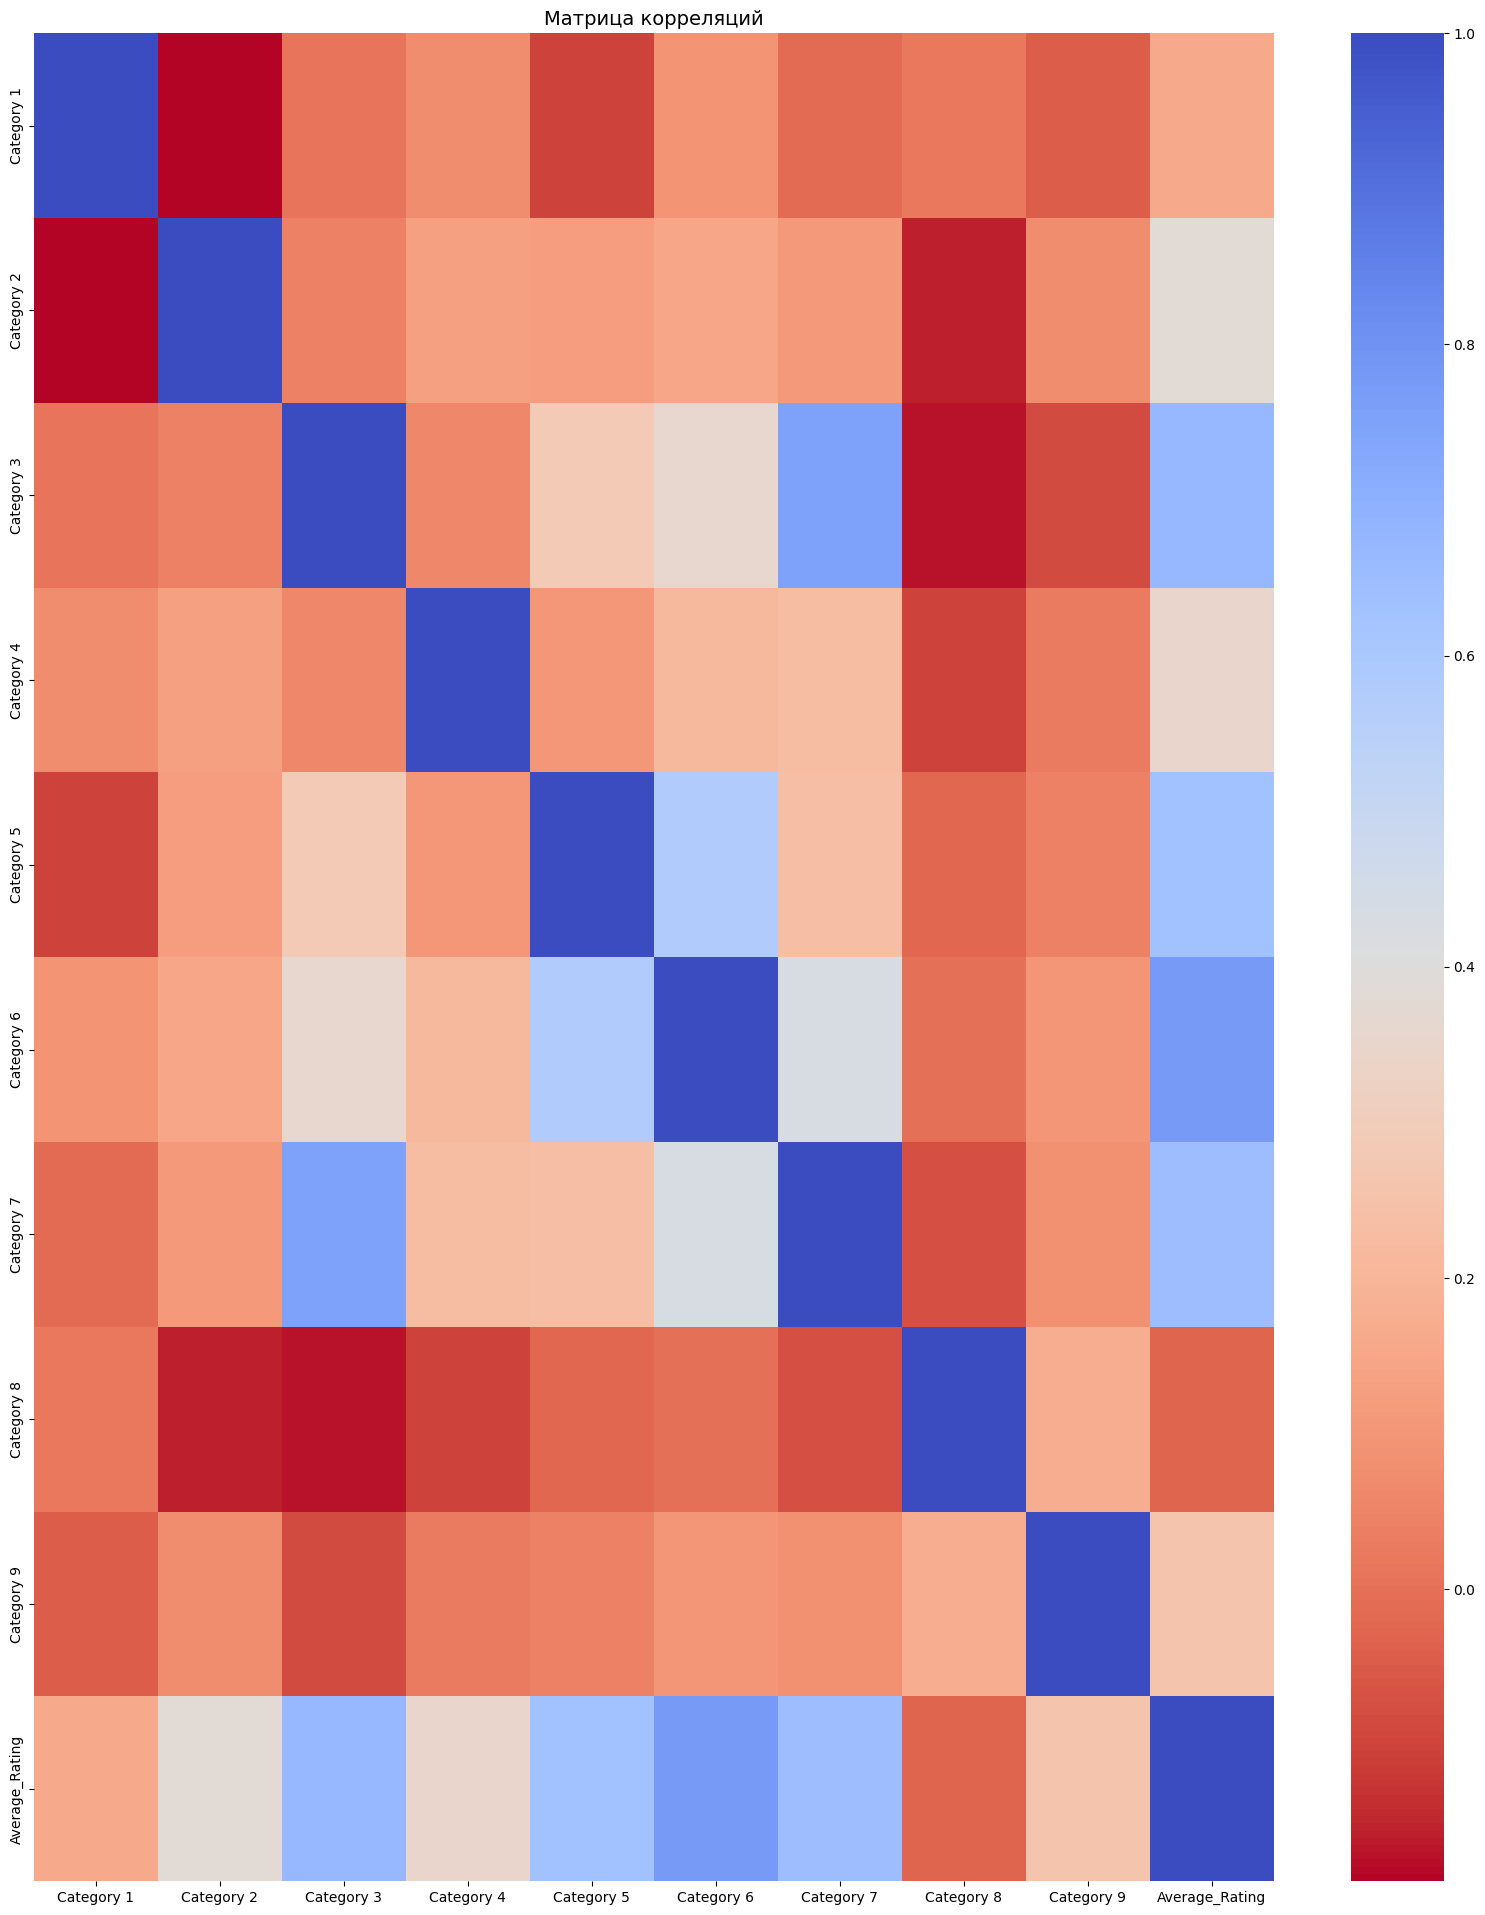

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций', fontsize=14)
plt.show()

средняя оценка зависит от категорий 3, 5, 6, 7

выясним, насколько не сбалансированы данные, для этого добавим столбик, показывающий, сколько людей поставили положительные оценки, а сколько - отрицательные

In [ ]:
new_df['Target_Column'] = (new_df['Average_Rating'] > 1.30).astype(int).replace({1: 1, 0: 2})

In [ ]:
new_df

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Average_Rating,Target_Column
0,0.93,1.80,2.29,0.62,0.80,2.42,3.19,2.79,1.82,1.851111,1
1,1.02,2.20,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.091111,1
2,1.22,0.80,0.54,0.53,0.24,1.54,3.18,2.80,1.31,1.351111,1
3,0.45,1.80,0.29,0.57,0.46,1.52,3.18,2.96,1.57,1.422222,1
4,0.51,1.20,1.18,0.57,1.54,2.02,3.18,2.78,1.18,1.573333,1
...,...,...,...,...,...,...,...,...,...,...,...
975,0.74,1.12,0.30,0.53,0.88,1.38,3.17,2.78,0.99,1.321111,1
976,1.25,0.92,1.12,0.38,0.78,1.68,3.18,2.79,1.34,1.493333,1
977,0.61,1.32,0.67,0.43,1.30,1.78,3.17,2.81,1.34,1.492222,1
978,0.93,0.20,0.13,0.43,0.30,0.40,3.18,2.98,1.12,1.074444,2


In [ ]:
print('оценка выше 1.3', round(new_df['Target_Column'].value_counts()[1]/len(new_df) * 100,2), '%')
print('оценка ниже 1.3', round(new_df['Target_Column'].value_counts()[2]/len(new_df) * 100,2), '%')

оценка выше 1.3 95.82 % человек
оценка ниже 1.3 4.18 % человек


количество в каждом классе

In [ ]:
print(new_df['Target_Column'].value_counts()[1])
print(new_df['Target_Column'].value_counts()[2])

939
41


Text(0.5, 1.0, 'Распределение классов \n (1: довольны || 2: не довольны)')

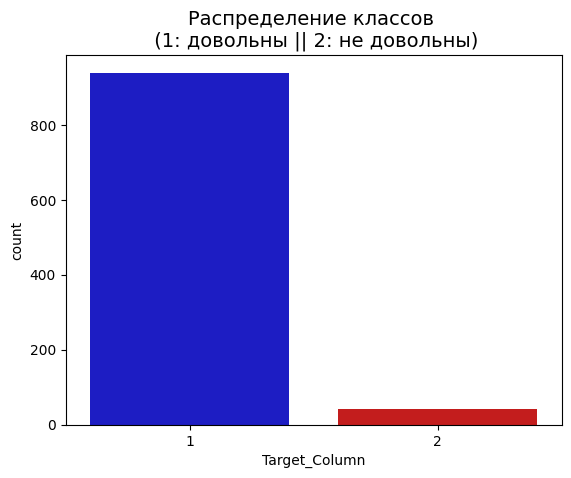

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Target_Column', data=new_df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (1: довольны || 2: не довольны)', fontsize=14)

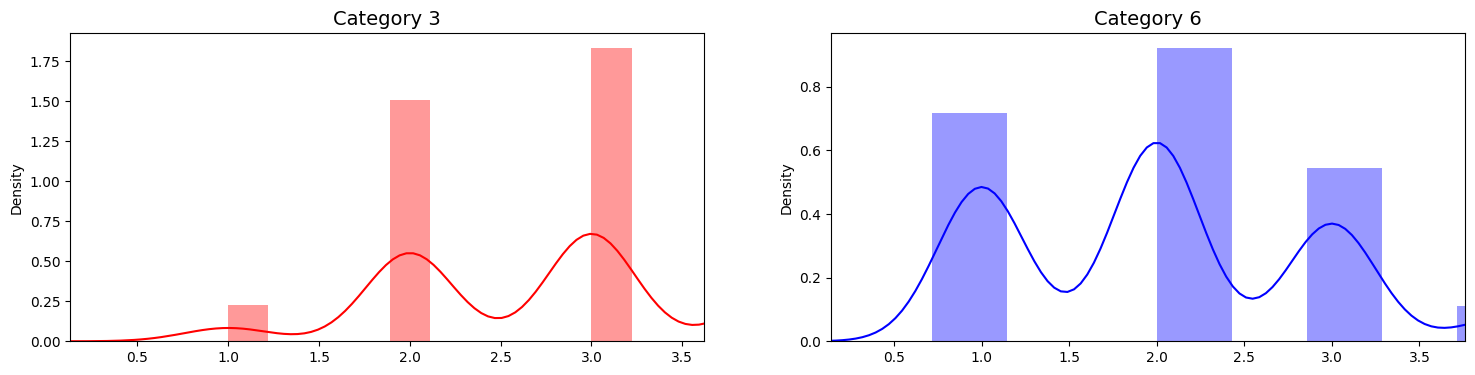

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

с_3 = new_df['Category 3'].values
с_6 = new_df['Category 6'].values

sns.distplot(ph, ax=ax[0], color='r')
ax[0].set_title('Category 3', fontsize=14)
ax[0].set_xlim([min(с_3), max(с_3)])

sns.distplot(mh, ax=ax[1], color='b')
ax[1].set_title('Category 6', fontsize=14)
ax[1].set_xlim([min(с_6), max(с_6)])

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [ ]:
X = new_df.drop(['Target_Column'], axis=1)
y = new_df['Target_Column']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (980, 10) | y shape: (980,) 


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

Метод Random Under-Sampling

In [ ]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.
# Перемешаем данные перед созданием подвыборок
df = new_df.sample(frac=1)
o_df = df.loc[df['Target_Column'] == 2]
p_df = df.loc[df['Target_Column'] == 1][:41] # берем последние 41
normal_distributed_df = pd.concat([o_df, p_df])
# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)
new_df.head()

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Average_Rating,Target_Column
384,0.64,1.20,0.14,0.22,0.10,0.38,3.17,2.85,1.15,1.094444,2
651,0.80,1.32,0.34,0.24,0.46,1.02,3.17,2.90,1.44,1.298889,2
239,2.08,0.48,0.18,0.15,0.10,0.14,3.18,2.95,1.15,1.156667,2
978,0.93,0.20,0.13,0.43,0.30,0.40,3.18,2.98,1.12,1.074444,2
213,0.51,1.32,0.24,0.38,0.42,1.30,3.18,2.79,1.34,1.275556,2


In [ ]:
new_df.shape

(82, 11)

Text(0.5, 1.0, 'Распределение классов \n (1: довольны || 2: нет)')

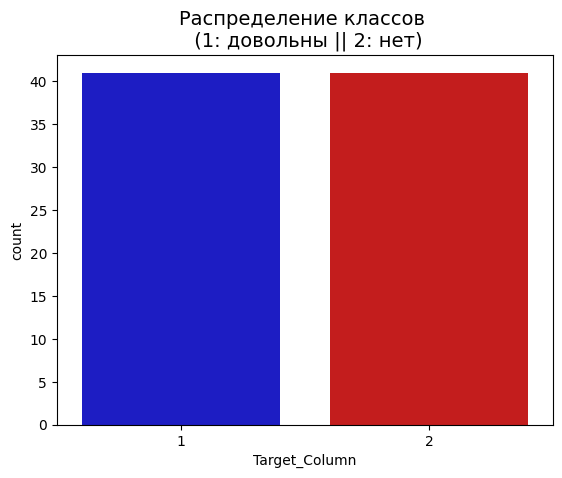

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Target_Column', data=new_df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (1: довольны || 2: нет)', fontsize=14)

матрица корреляций

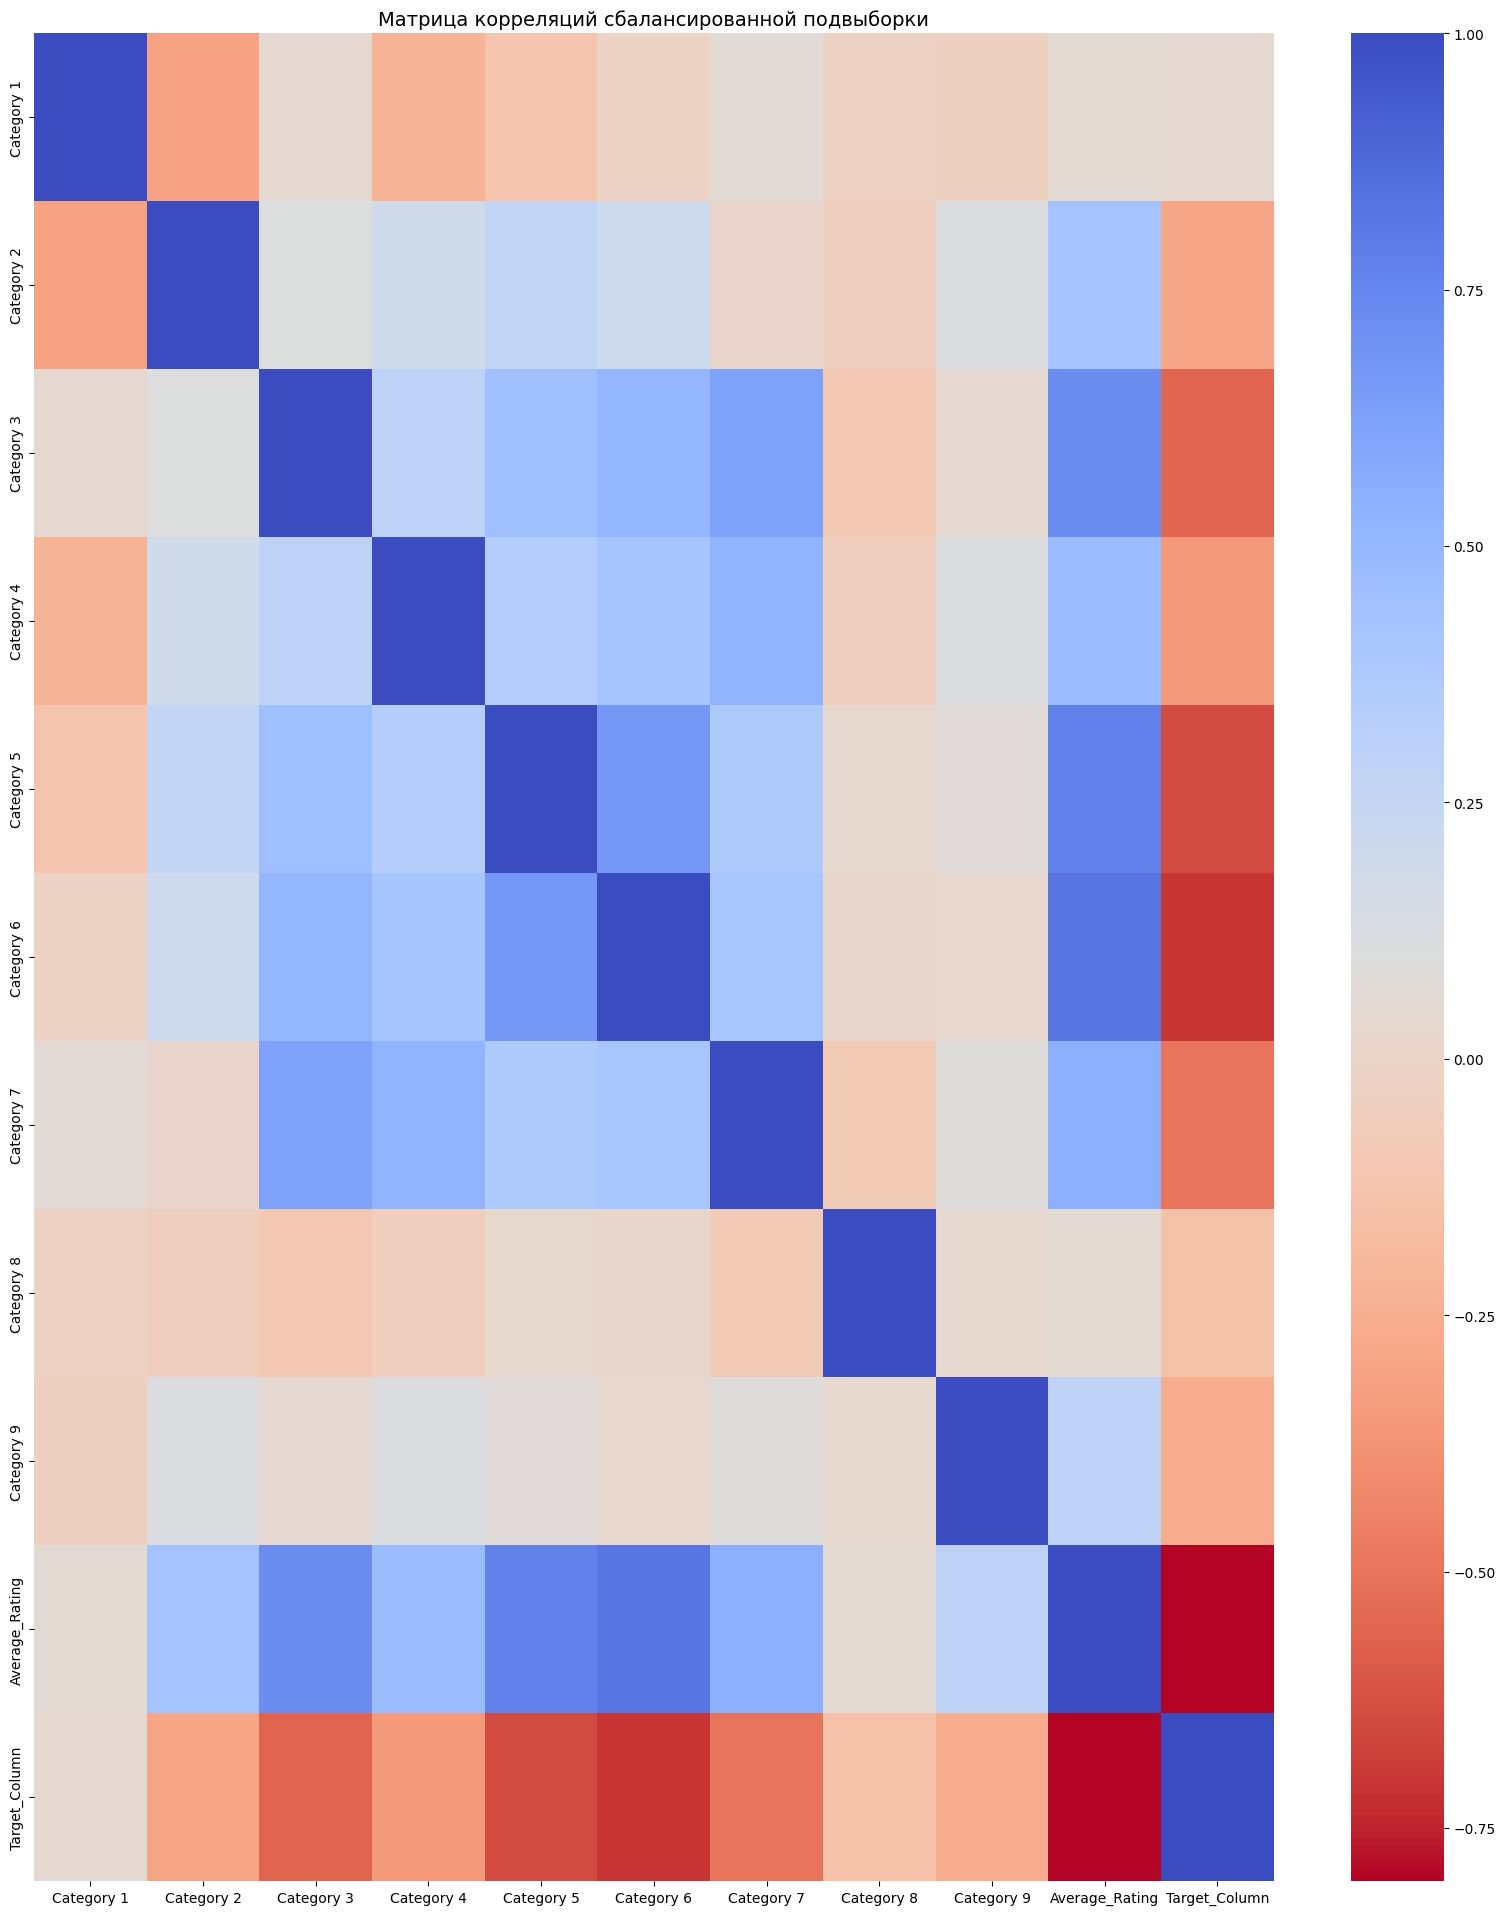

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

отрицательную корреляцию имеют 1 и 8

положительную - 3, 5, 6

boxplot

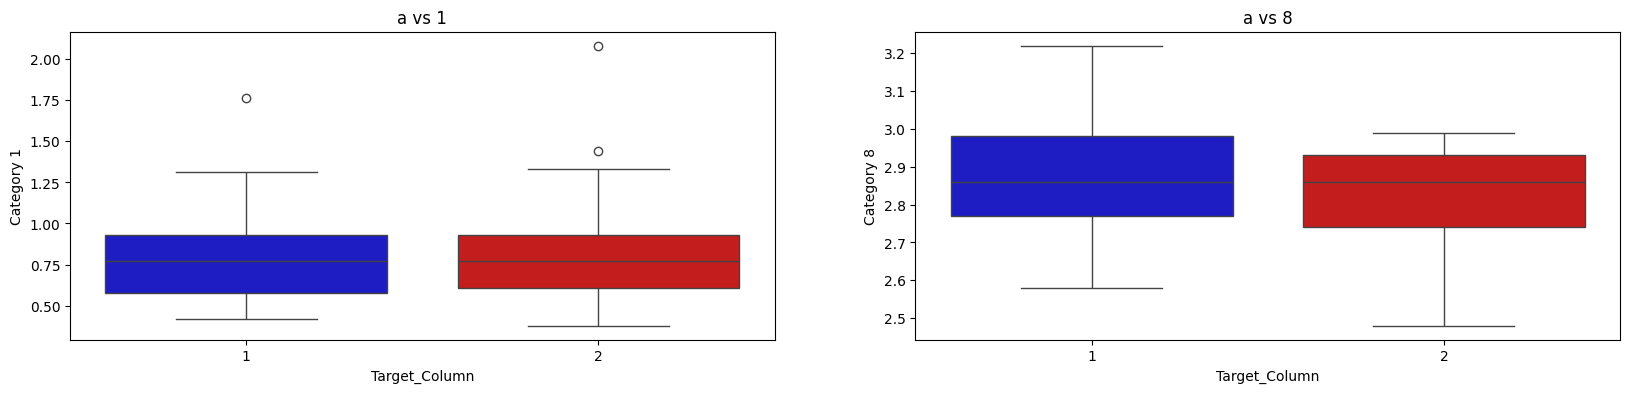

In [ ]:
f, axes = plt.subplots(ncols=2, figsize=(20,4))

sns.boxplot(x='Target_Column', y='Category 1', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('a vs 1')

sns.boxplot(x='Target_Column', y='Category 8', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('a vs 8')

plt.show()

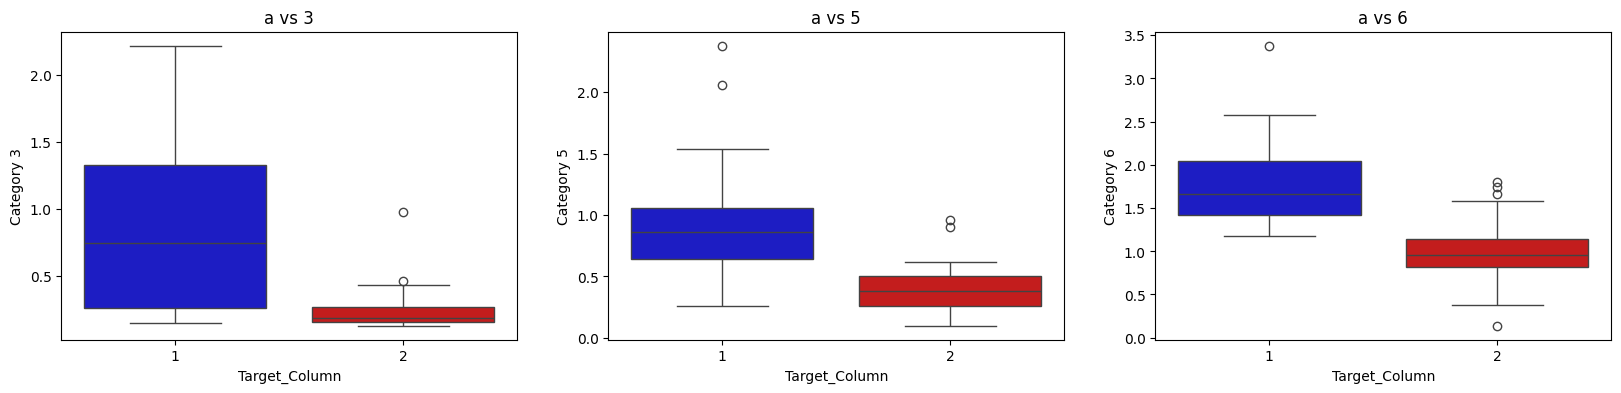

In [ ]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

sns.boxplot(x='Target_Column', y='Category 3', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('a vs 3')

sns.boxplot(x='Target_Column', y='Category 5', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('a vs 5')

sns.boxplot(x='Target_Column', y='Category 6', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('a vs 6')

plt.show()

удаление выбросов

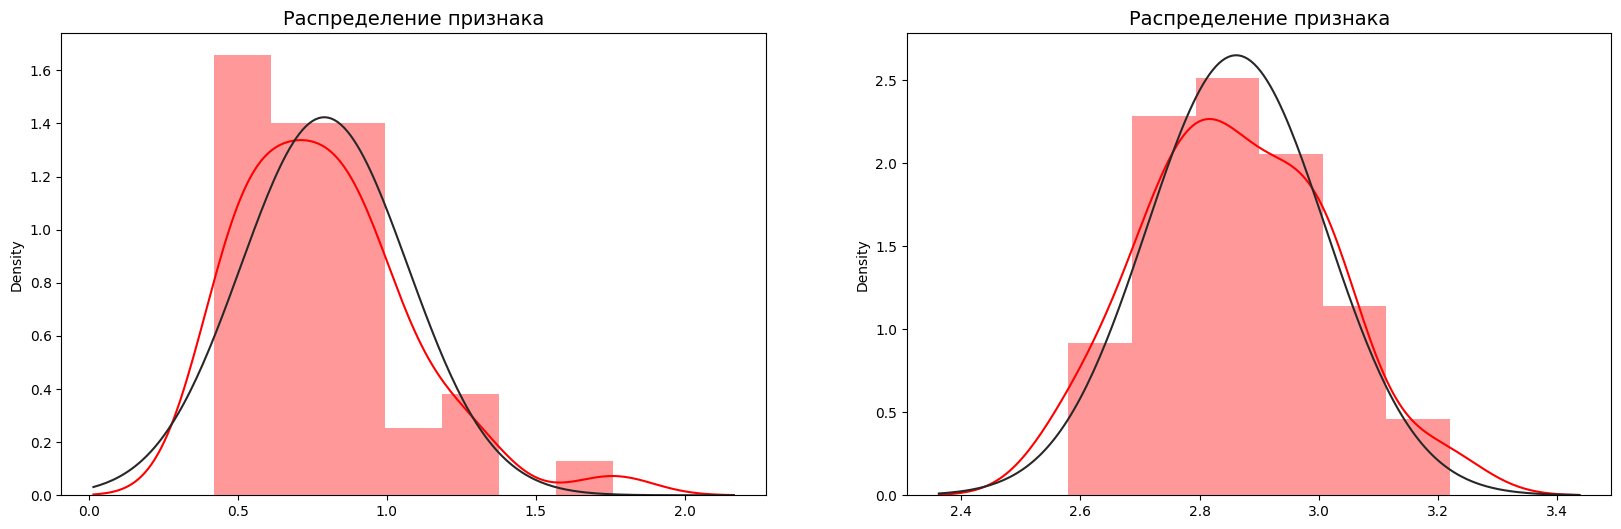

In [ ]:
from scipy.stats import norm

f, (ax1, ax2) = plt.subplots(1,2, figsize=(20, 6))

####
s_dist = new_df['Category 1'].loc[new_df['Target_Column'] == 1].values

sns.distplot(s_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака', fontsize=14)

####
r_dist = new_df['Category 8'].loc[new_df['Target_Column'] == 1].values

sns.distplot(r_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака', fontsize=14)

plt.show()

In [ ]:

s = new_df['Category 1'].loc[new_df['Target_Column'] == 1].values
q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
s_iqr = q75 - q25
print('iqr: {}'.format(s_iqr))

s_cut_off = s_iqr * 1.5
s_lower, s_upper = q25 - s_cut_off, q75 + s_cut_off
print('Порог: {}'.format(s_cut_off))
print('s нижняя граница: {}'.format(s_lower))
print('s верхняя граница: {}'.format(s_upper))

outliers = [x for x in s if x < s_lower or x > s_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['Category 1'] > s_upper) | (new_df['Category 1'] < s_lower)].index)
print('----' * 44)


r = new_df['Category 8'].loc[new_df['Target_Column'] == 1].values
q25, q75 = np.percentile(r, 25), np.percentile(r, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
r_iqr = q75 - q25
print('iqr: {}'.format(r_iqr))

r_cut_off = r_iqr * 1.5
r_lower, r_upper = q25 - r_cut_off, q75 + r_cut_off
print('Порог: {}'.format(r_cut_off))
print('r нижняя граница: {}'.format(r_lower))
print('r верхняя граница: {}'.format(r_upper))

outliers = [x for x in r if x < r_lower or x > r_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['Category 8'] > r_upper) | (new_df['Category 8'] < r_lower)].index)
print('----' * 44)


Квартиль 25: 0.58 | Квартиль 75: 0.93
iqr: 0.3500000000000001
Порог: 0.5250000000000001
s нижняя граница: 0.05499999999999983
s верхняя граница: 1.455
Количество выбросов: 1
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 2.77 | Квартиль 75: 2.98
iqr: 0.20999999999999996
Порог: 0.31499999999999995
r нижняя граница: 2.455
r верхняя граница: 3.295
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
new_df = new_df_without_outliers

понижение размерности и кластеризация

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('Target_Column', axis=1)
y = new_df['Target_Column']

# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 0.33 сек
PCA заняло 0.0016 сек
Truncated SVD заняло 0.0018 сек


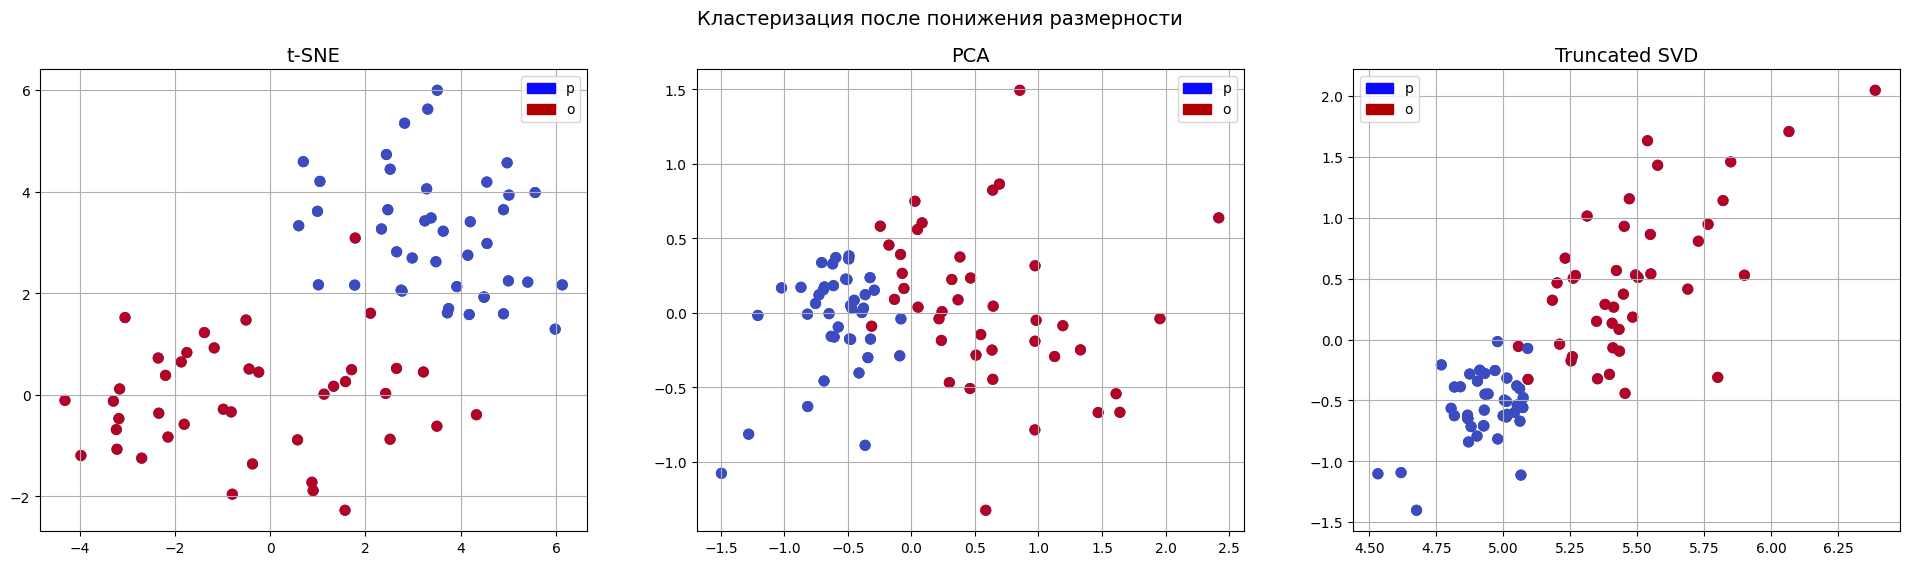

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='p')
red_patch = mpatches.Patch(color='#AF0000', label='o')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='p', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='o', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='p', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='o', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='p', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='o', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

НАКОНЕЦ-ТО УСПЕШНАЯ КЛАСТЕРИЗАЦИЯ!!!

часть 2

In [ ]:
new_df

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Average_Rating,Target_Column
384,0.64,1.20,0.14,0.22,0.10,0.38,3.17,2.85,1.15,1.094444,2
651,0.80,1.32,0.34,0.24,0.46,1.02,3.17,2.90,1.44,1.298889,2
239,2.08,0.48,0.18,0.15,0.10,0.14,3.18,2.95,1.15,1.156667,2
978,0.93,0.20,0.13,0.43,0.30,0.40,3.18,2.98,1.12,1.074444,2
213,0.51,1.32,0.24,0.38,0.42,1.30,3.18,2.79,1.34,1.275556,2
...,...,...,...,...,...,...,...,...,...,...,...
496,0.51,0.88,0.26,0.48,0.96,1.42,3.17,2.88,1.02,1.286667,2
118,0.54,1.20,1.17,0.45,1.04,1.38,3.18,2.58,1.82,1.484444,1
752,1.22,1.36,1.33,0.59,1.18,2.24,3.19,2.77,1.66,1.726667,1
285,0.51,1.44,0.26,0.48,0.34,0.82,3.18,2.86,1.73,1.291111,2


приводим большой файл к тому же виду

In [ ]:
df = pd.read_csv("tripadvisor_review.csv")

In [ ]:
df = df.drop('User ID', axis=1)

In [ ]:
df = df.drop('Category 10', axis=1)

In [ ]:
df['Average_Rating'] = df.mean(axis=1)

In [ ]:
df['Target_Column'] = (df['Average_Rating'] > 1.30).astype(int).replace({1: 1, 0: 2})

In [ ]:
df

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Average_Rating,Target_Column
0,0.93,1.80,2.29,0.62,0.80,2.42,3.19,2.79,1.82,1.851111,1
1,1.02,2.20,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.091111,1
2,1.22,0.80,0.54,0.53,0.24,1.54,3.18,2.80,1.31,1.351111,1
3,0.45,1.80,0.29,0.57,0.46,1.52,3.18,2.96,1.57,1.422222,1
4,0.51,1.20,1.18,0.57,1.54,2.02,3.18,2.78,1.18,1.573333,1
...,...,...,...,...,...,...,...,...,...,...,...
975,0.74,1.12,0.30,0.53,0.88,1.38,3.17,2.78,0.99,1.321111,1
976,1.25,0.92,1.12,0.38,0.78,1.68,3.18,2.79,1.34,1.493333,1
977,0.61,1.32,0.67,0.43,1.30,1.78,3.17,2.81,1.34,1.492222,1
978,0.93,0.20,0.13,0.43,0.30,0.40,3.18,2.98,1.12,1.074444,2


работаем с мелким

In [ ]:
X = new_df.drop('Target_Column', axis=1)
y = new_df['Target_Column']

In [ ]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Выберем несколько простых моделей из библиотеки sklearn

classifiers = {
    "LogisiticRegression": LogisticRegression(),  # Логистическая регрессия
    "KNearest": SVC(),  # Метод опорных векторов
    "Support Vector Classifier": KNeighborsClassifier(),# Метод ближайших соседей
    "DecisionTreeClassifier": DecisionTreeClassifier() # Решающее дерево
}

In [ ]:
from sklearn.model_selection import cross_val_score

for key, classifier in classifiers.items():
    #classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Модель ", classifier.__class__.__name__, "получила на обучающей выборке", round(training_score.mean(), 2) * 100, "% accuracy score")

Модель  LogisticRegression получила на обучающей выборке 97.0 % accuracy score
Модель  SVC получила на обучающей выборке 96.0 % accuracy score
Модель  KNeighborsClassifier получила на обучающей выборке 98.0 % accuracy score
Модель  DecisionTreeClassifier получила на обучающей выборке 100.0 % accuracy score


In [ ]:
# Используем поиск по сетке для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Логистическая регрессия
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)

# Выбираем лучшую модель
log_reg = grid_log_reg.best_estimator_ #  для Логистическая регрессия

# Метод ближайших соседей
knears_params = {"n_neighbors": list(range(2,7,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)

knears_neighbors = grid_knears.best_estimator_# для  K ближайший соседей

# Метод опорных векторов
x = [1.0, 1000.0]
y = [0.9]
z = [4]
svc_params=[
            {'C': x,'kernel': ['rbf'],'gamma': y} ,
            {'C': x,'kernel': ['poly'],'gamma': y,'degree': z}
           ]
grid_svc=GridSearchCV(estimator = SVC(),
                        param_grid = svc_params,
                        scoring='accuracy',
                        cv=3,
                        n_jobs=-1)

grid_svc.fit(X_train, y_train)

svc = grid_svc.best_estimator_#  для SVM

# Решающее дерево
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,7,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

tree_clf = grid_tree.best_estimator_#  для решающий деревьев

In [ ]:
# Проверим, как поменялись метрики

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  99.49%
Knears Neighbors Cross Validation Score 98.09%
Support Vector Classifier Cross Validation Score 99.36%
DecisionTree Classifier Cross Validation Score 100.0%


стало лучше, но страшновато выглядит

In [ ]:
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

skf = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

from sklearn.metrics import (precision_score, roc_auc_score, recall_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve, accuracy_score)

undersample_X = df.drop('Target_Column', axis=1)
undersample_y = df['Target_Column']

undersample_Xtrain, undersample_Xtest, undersample_ytrain, undersample_ytest = train_test_split(undersample_X, undersample_y,
                                                                                                test_size = 0.2,
                                                                                                random_state=42,
                                                                                                stratify = undersample_y)

undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Метод NearMiss
X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss распределение классов: {}'.format(Counter(y_nearmiss)))
# Использовать сэмплирование будем во время кросс-валидации

for train, test in skf.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg)#
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])#
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])#

    undersample_accuracy.append(undersample_pipeline.score(undersample_Xtrain[test],
                                                           undersample_ytrain[test]))
    undersample_precision.append(precision_score(undersample_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(undersample_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(undersample_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(undersample_ytrain[test], undersample_prediction))

NearMiss распределение классов: Counter({np.int64(1): 41, np.int64(2): 41})


In [ ]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve
import seaborn as sn

кривая обучения

In [ ]:
def plot_learning_curves(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)

    # Первая модель
    train_sizes, train_scores, test_scores = learning_curve(estimator1, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)#
    train_scores_mean = np.mean(train_scores, axis=1)#
    train_scores_std = np.std(train_scores, axis=1)#
    test_scores_mean = np.mean(test_scores, axis=1)#
    test_scores_std = np.std(test_scores, axis=1)#
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Размер выборки')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Вторая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Размер выборки')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")


    # Третья модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")


    # Четвертая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")

    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

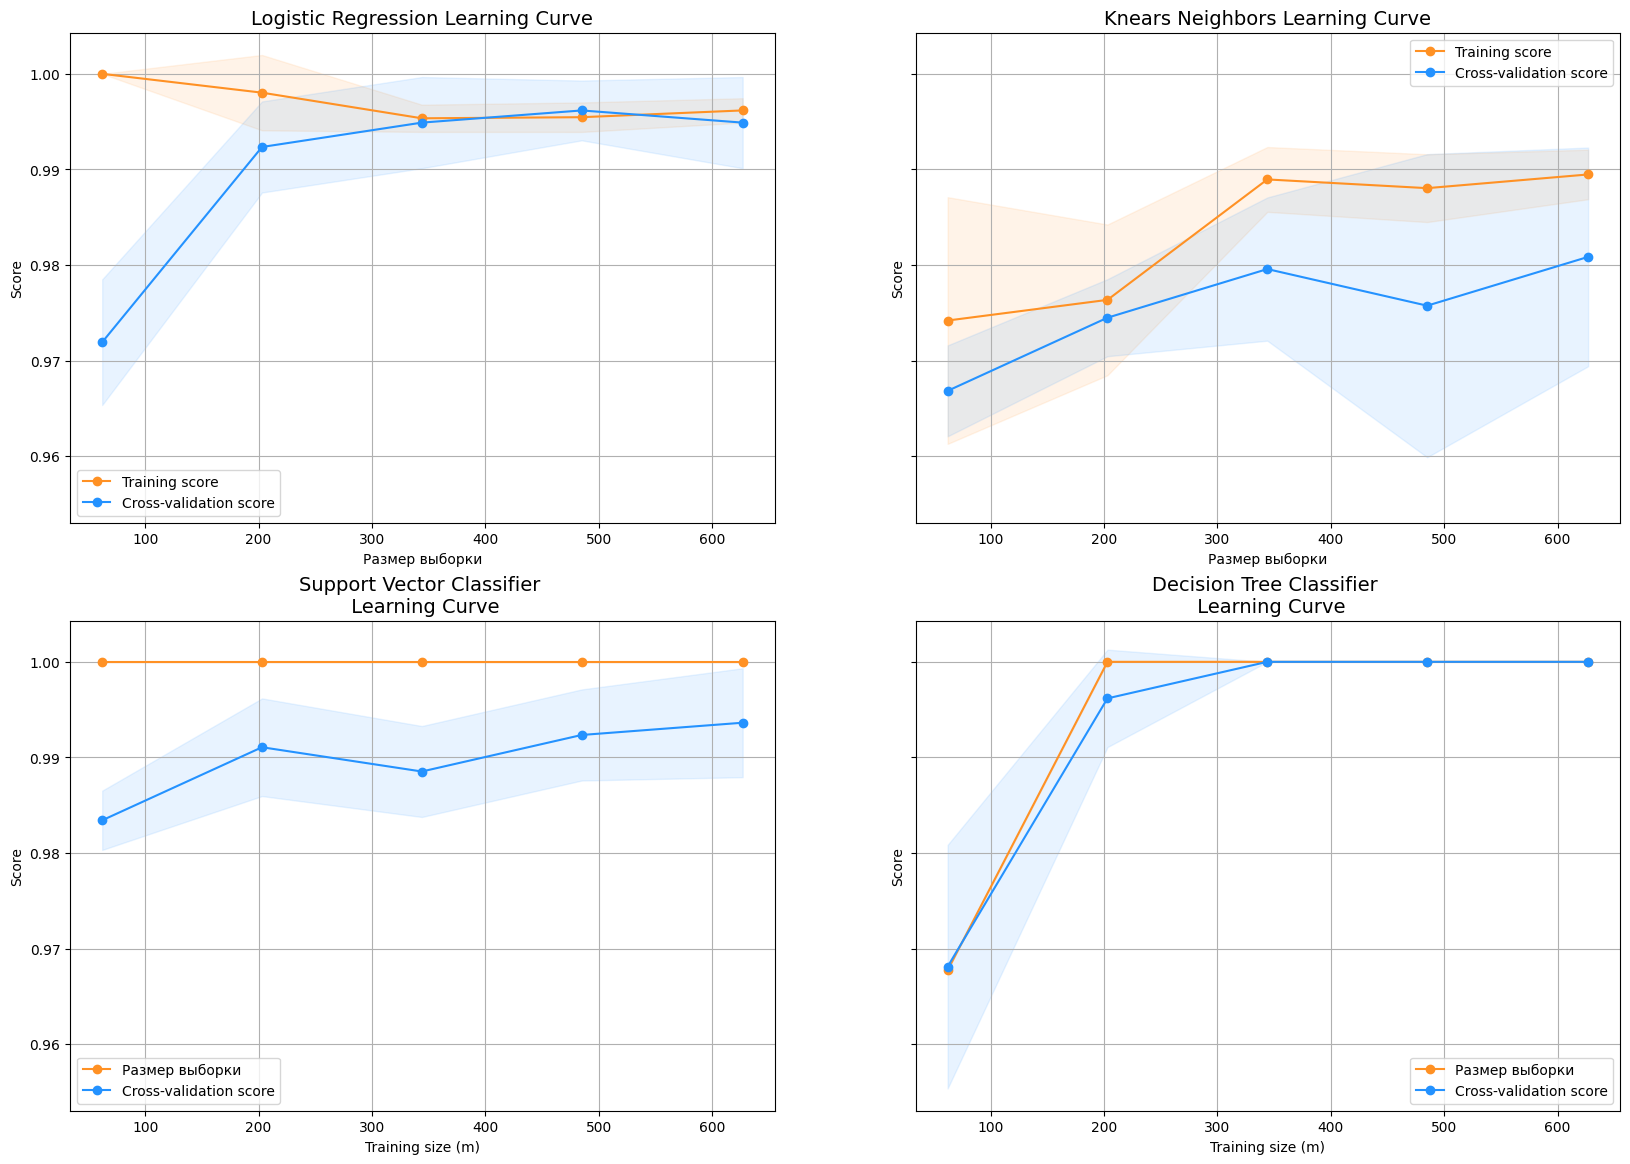

In [ ]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curves(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train)

логистическая модель лучше всего

In [ ]:
from sklearn.model_selection import cross_val_predict

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv=5,
                             method="decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [ ]:
print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.9990719444780696
KNears Neighbors:  0.8451559536779244
Support Vector Classifier:  0.9986280918371464
Decision Tree Classifier:  1.0


SMOTE метод (Over-Sampling)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('Target_Column', axis=1)
y = df['Target_Column']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Распределение классов: 

Обучающий набор: [0.95663265 0.04336735]
Тестовый набор: [0.96428571 0.03571429]


In [ ]:
tuned_classifiers = {
    "LogisiticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    "Support Vector Classifier": svc,
    "DecisionTreeClassifier": tree_clf
}

#Making our Classifiers train with the tuned parameters
for key, classifier in tuned_classifiers.items():
    score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f'{key} Cross Validation Score: {round(score.mean() * 100, 2)}%')

LogisiticRegression Cross Validation Score: 99.49%
Knears Neighbors Cross Validation Score: 98.09%
Support Vector Classifier Cross Validation Score: 99.36%
DecisionTreeClassifier Cross Validation Score: 100.0%


In [ ]:
from imblearn.combine import SMOTETomek  # Комбинированный метод

for key, classifier in tuned_classifiers.items():
    #Только oversampling
    steps = [('sampler', SMOTE(sampling_strategy='auto', k_neighbors=5)), ('model', classifier)]

    # Pipeline с комбинированным методом

    FiPipeline = Pipeline(steps=steps)
    scores = cross_val_score(FiPipeline, X, y, cv=sss)
    print(f"Classifiers: {key} Has a training score of, {round(scores.mean() * 100, 2)} % accuracy score")

Classifiers: LogisiticRegression Has a training score of, 98.57 % accuracy score
Classifiers: Knears Neighbors Has a training score of, 96.12 % accuracy score
Classifiers: Support Vector Classifier Has a training score of, 99.39 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of, 100.0 % accuracy score


че-то коллаб ругался на код из методички, пришлось чуть-чуть подобрать параметры

In [ ]:
# Сначала посмотрим распределение классов, чтобы подобрать правильные параметры
print("Распределение классов в y:")
print(y.value_counts())
minority_count = y.value_counts().min()
majority_count = y.value_counts().max()
print(f"Миноритарный класс: {minority_count} образцов")
print(f"Мажоритарный класс: {majority_count} образцов")

# Более безопасные параметры
smote_strategy = 0.5
under_strategy = 0.8

# taking a fold of a data to do GridSearchCV for best parameters for SMOTE
for train_index, test_index in sss.split(X, y):
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]
    break

# creating a ML pipeline с исправленными параметрами
model = Pipeline([
    ('sampling', SMOTE(sampling_strategy=smote_strategy, random_state=42)),
    ('Random', RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)),
    ('classification', log_reg)
])

# Running GridSearchCV on our ML pipeline by varying the k_neighbors from 1 to 10
SMOTE_KN = GridSearchCV(model, {'sampling__k_neighbors': list(range(2, 10))}, cv=3)
SMOTE_KN.fit(original_Xtrain, original_ytrain)

print(SMOTE_KN.best_estimator_)
print(SMOTE_KN.best_score_)
print(SMOTE_KN.best_params_)

# Training logistic regression classifier using SMOTE best parameter value
log_reg_score = cross_val_score(SMOTE_KN.best_estimator_, original_Xtrain, original_ytrain, cv=3)

print(f'Logistic Regression Cross Validation Score: {round(log_reg_score.mean() * 100, 2)}%')

Распределение классов в y:
Target_Column
1    939
2     41
Name: count, dtype: int64
Миноритарный класс: 41 образцов
Мажоритарный класс: 939 образцов
Pipeline(steps=[('sampling',
                 SMOTE(k_neighbors=7, random_state=42, sampling_strategy=0.5)),
                ('Random',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.8)),
                ('classification', LogisticRegression(C=100))])
0.9859563432872198
{'sampling__k_neighbors': 7}
Logistic Regression Cross Validation Score: 98.6%


In [ ]:
labels = ['dovolny', 'ne dovolny']

best_est = SMOTE_KN.best_estimator_
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names=labels))

              precision    recall  f1-score   support

     dovolny       1.00      0.98      0.99       188
  ne dovolny       0.73      1.00      0.84         8

    accuracy                           0.98       196
   macro avg       0.86      0.99      0.92       196
weighted avg       0.99      0.98      0.99       196



In [ ]:
y_score = best_est.decision_function(original_Xtest)

In [ ]:
sm = SMOTE(sampling_strategy='minority', random_state=42)

# Применим SMOTE после кросс-валидации
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

In [ ]:
# Обучим логистическую регрессию
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Время обучения: {} сек".format(t1 - t0))

Время обучения: 0.013726949691772461 сек


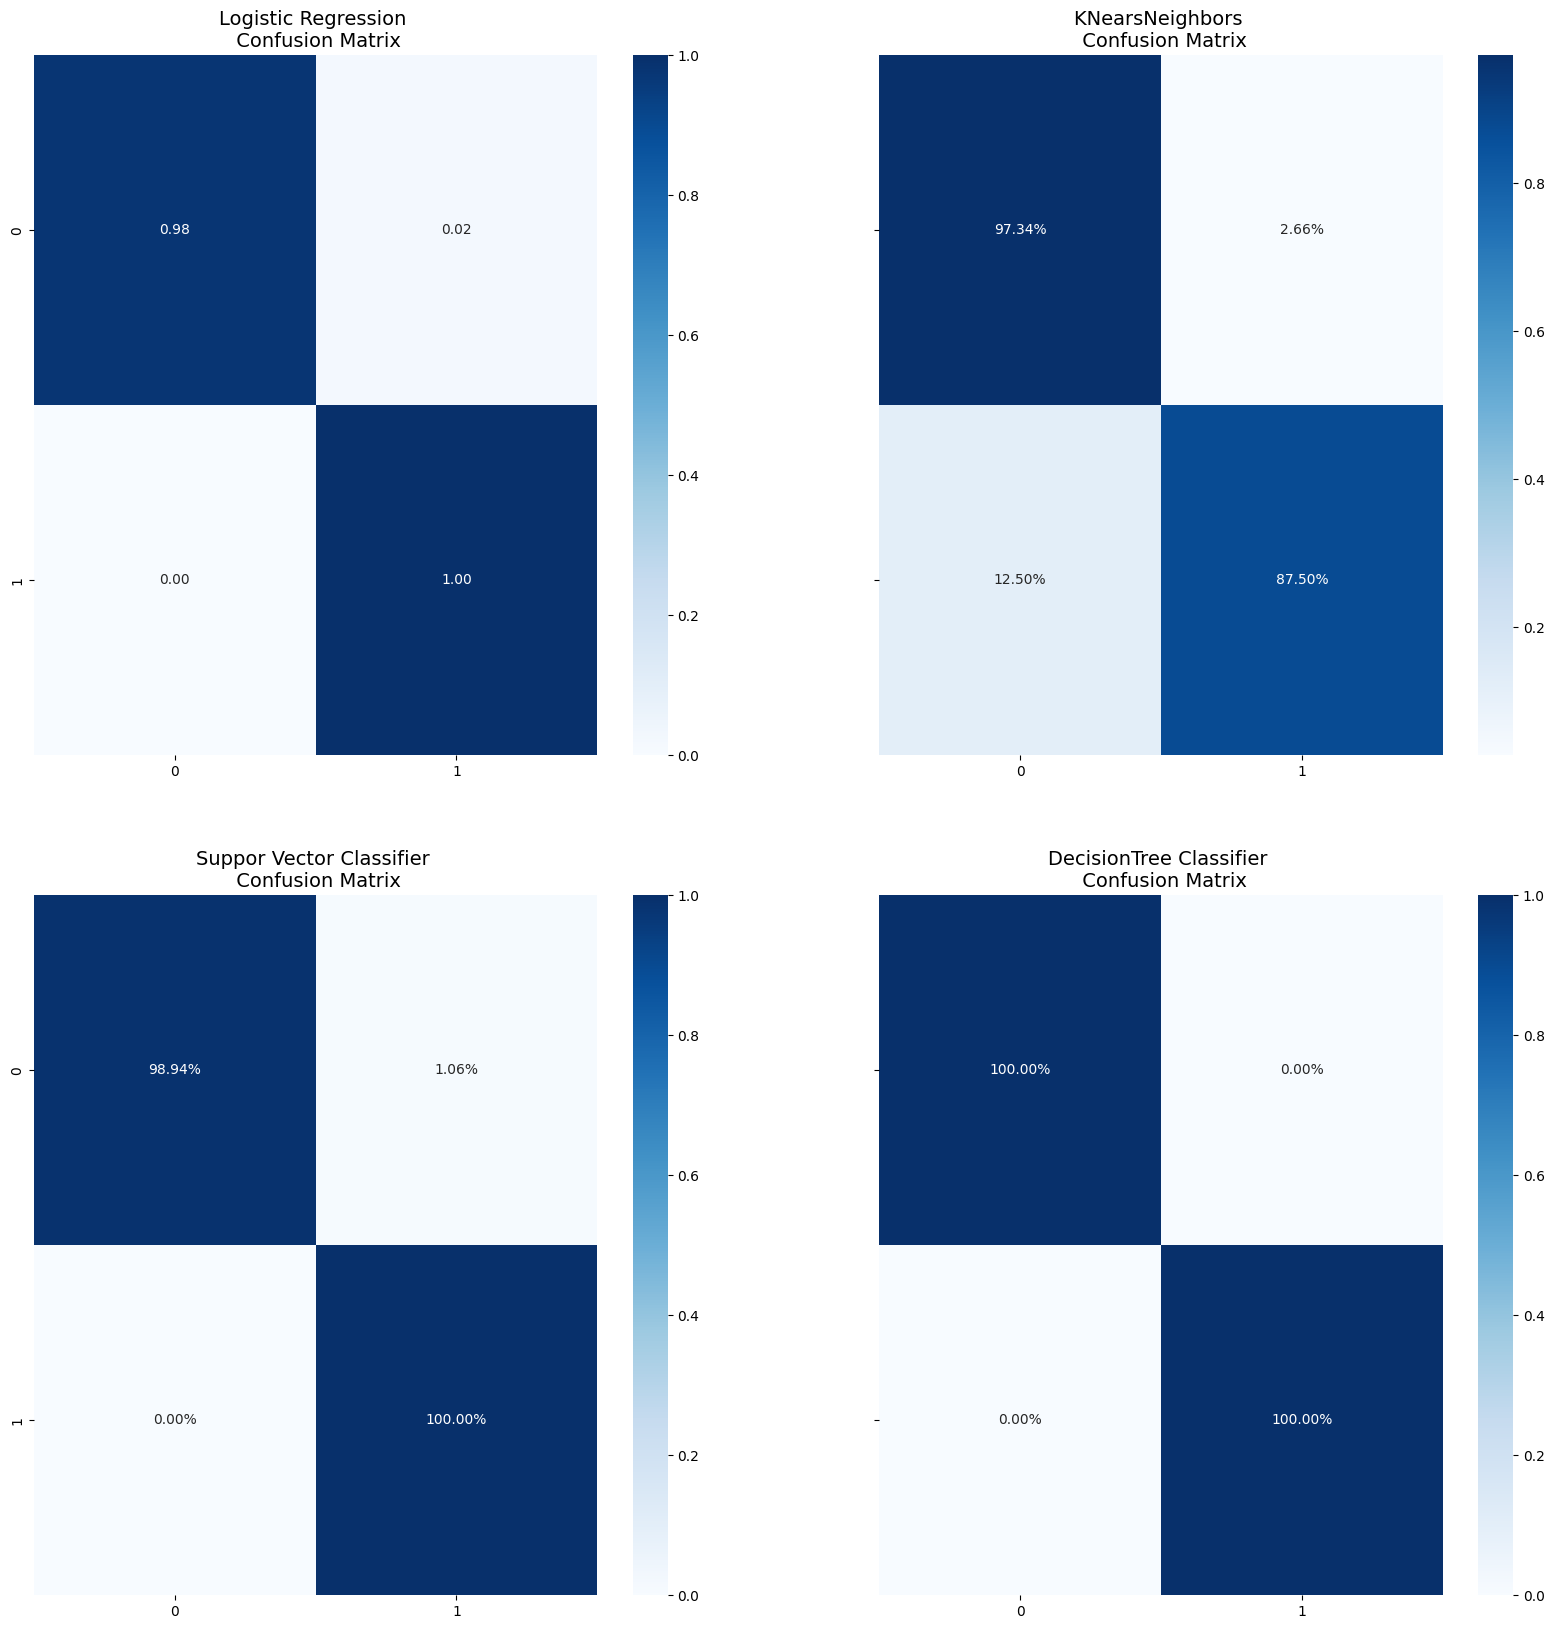

In [ ]:
y_pred_log_reg = best_est.predict(X_test)

# Другие модели
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg, normalize='true')
kneighbors_cf = confusion_matrix(y_test, y_pred_knear, normalize='true')
svc_cf = confusion_matrix(y_test, y_pred_svc, normalize='true')
tree_cf = confusion_matrix(y_test, y_pred_tree, normalize='true')

fig,  ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2,figsize=(20,20), sharey=True)
# Построим матрицы ошибок
sns.heatmap(ax=ax1, data=log_reg_cf, annot=True, fmt='.2f', cmap='Blues')
ax1.set_title("Logistic Regression \n Confusion Matrix", fontsize=14)



#
sns.heatmap(ax=ax2,data=kneighbors_cf, annot=True, fmt='.2%', cmap='Blues')
ax2.set_title("KNearsNeighbors \n Confusion Matrix", fontsize=14)


#
sns.heatmap(ax=ax3, data=svc_cf, annot=True,
            fmt='.2%', cmap='Blues')
ax3.set_title("Suppor Vector Classifier \n Confusion Matrix", fontsize=14)



#
sns.heatmap(ax=ax4, data=tree_cf, annot=True,
            fmt='.2%', cmap='Blues')
ax4.set_title("DecisionTree Classifier \n Confusion Matrix", fontsize=14)


plt.show()

ну соседи будто получше

метрики

In [ ]:
from sklearn.metrics import classification_report



print('Logistic Regression:')
#
y_pred=  best_est.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('KNears Neighbors:')
#
y_pred=  knears_neighbors.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('Support Vector Classifier:')
#
y_pred=  svc.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('Decision Tree Classifier:')
#
y_pred=  tree_clf.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

Logistic Regression:
              precision    recall  f1-score   support

     dovolny       1.00      0.98      0.99       188
  ne dovolny       0.73      1.00      0.84         8

    accuracy                           0.98       196
   macro avg       0.86      0.99      0.92       196
weighted avg       0.99      0.98      0.99       196

KNears Neighbors:
              precision    recall  f1-score   support

     dovolny       0.99      0.99      0.99       188
  ne dovolny       0.78      0.88      0.82         8

    accuracy                           0.98       196
   macro avg       0.89      0.93      0.91       196
weighted avg       0.99      0.98      0.99       196

Support Vector Classifier:
              precision    recall  f1-score   support

     dovolny       1.00      0.99      1.00       188
  ne dovolny       0.89      1.00      0.94         8

    accuracy                           0.99       196
   macro avg       0.94      1.00      0.97       196
weighted

In [ ]:
# Логистическая регрессия с under-sampling
y_pred = log_reg.predict(original_Xtest)
undersample_score = accuracy_score(original_ytest, y_pred)

# Логистическая регрессия с over-sampling
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)

d = {'Метод': ['Random Under-Sampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

final_df

,Метод,Score
0,Random Under-Sampling,0.984694
1,Oversampling (SMOTE),0.984694


оба метода справились одинаково, скорее всего это из-за того, что изначально очень красиво классы разделились на графиках во время кластеризации

часть 3

In [ ]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Dovolny", "Ne dovolny"]

In [ ]:
print(df.shape)
print(df.describe())

(980, 11)
       Category 1  Category 2  Category 3  Category 4  Category 5  Category 6  \
count  980.000000  980.000000  980.000000  980.000000  980.000000  980.000000   
mean     0.893194    1.352612    1.013306    0.532500    0.939735    1.842898   
std      0.326912    0.478280    0.788607    0.279731    0.437430    0.539538   
min      0.340000    0.000000    0.130000    0.150000    0.060000    0.140000   
25%      0.670000    1.080000    0.270000    0.410000    0.640000    1.460000   
50%      0.830000    1.280000    0.820000    0.500000    0.900000    1.800000   
75%      1.020000    1.560000    1.572500    0.580000    1.200000    2.200000   
max      3.220000    3.640000    3.620000    3.440000    3.300000    3.760000   

       Category 7  Category 8  Category 9  Average_Rating  Target_Column  
count  980.000000  980.000000  980.000000      980.000000     980.000000  
mean     3.180939    2.835061    1.569439        1.573298       1.041837  
std      0.007824    0.137505    0.

пропуски

In [ ]:
df.isnull().values.any()

np.False_

In [ ]:
df['Target_Column'].value_counts()

,count
Target_Column,
1,939
2,41


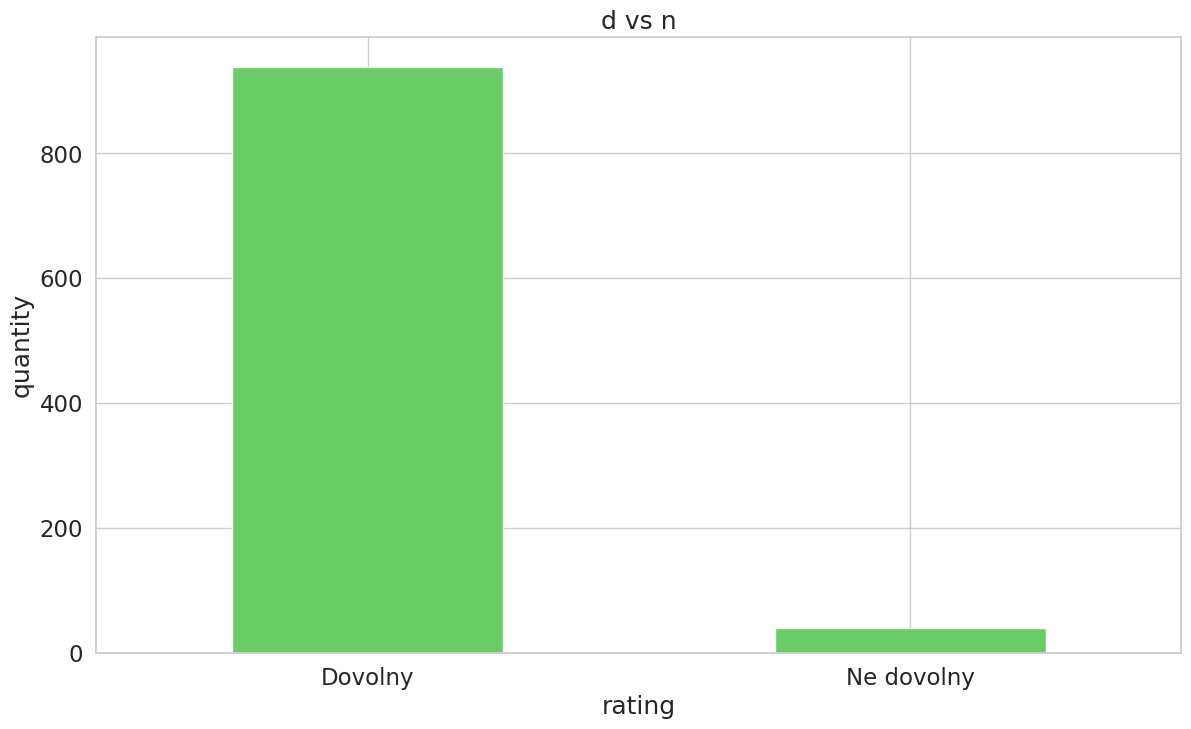

In [ ]:
count_classes = pd.value_counts(df['Target_Column'], sort = True)
count_classes.plot(kind = 'bar', rot=0, color="g")
plt.title("d vs n")
plt.xticks(range(2), LABELS)
plt.xlabel("rating")
plt.ylabel("quantity");

In [ ]:
d = df[df.Target_Column == 1]
n = df[df.Target_Column == 2]

In [ ]:
n.shape

(41, 11)

In [ ]:
d.shape

(939, 11)

In [ ]:
n.columns = [col.replace(' ', '_') for col in new_df.columns]

In [ ]:
d.columns = [col.replace(' ', '_') for col in new_df.columns]

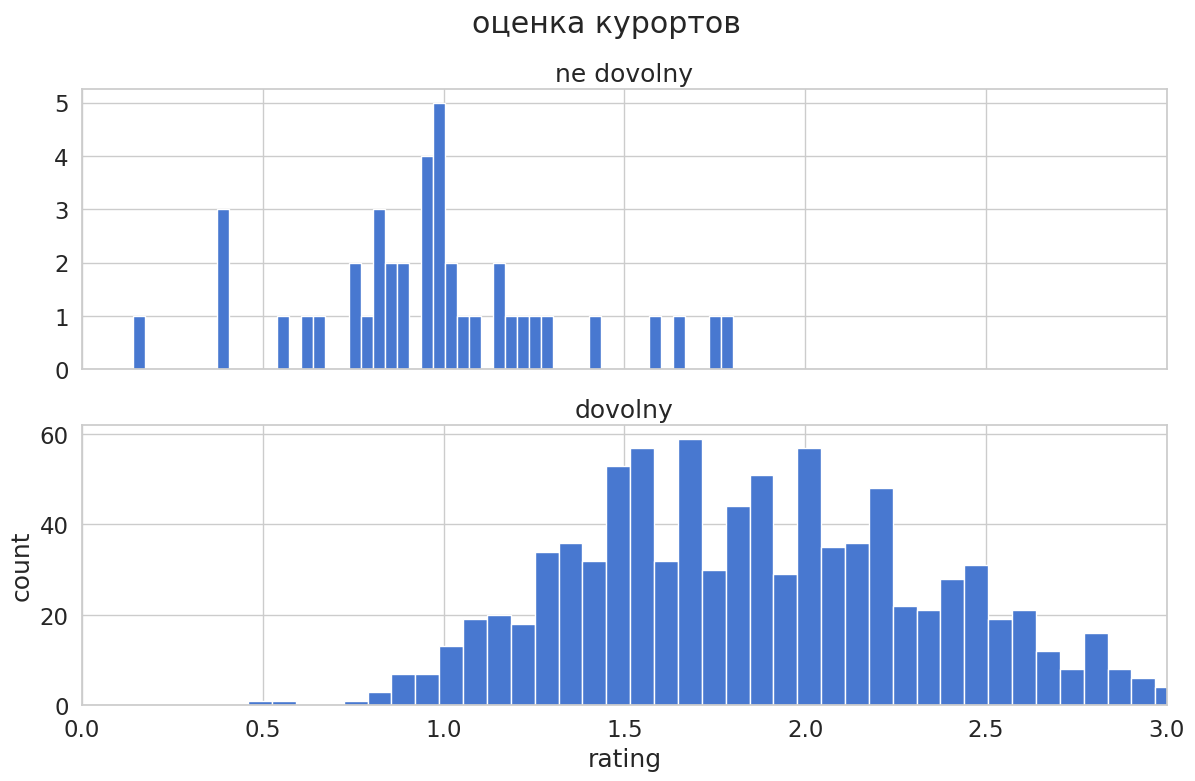

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('оценка курортов')

bins = 50

ax1.hist(n.Category_6, bins = bins)
ax1.set_title('ne dovolny')

ax2.hist(d.Category_6, bins = bins)
ax2.set_title('dovolny')

plt.xlabel('rating')
plt.ylabel('count')
plt.xlim((0, 3))
#plt.yscale('log')
plt.show();

курорт очень влияет на оценку всего отдыха в целом

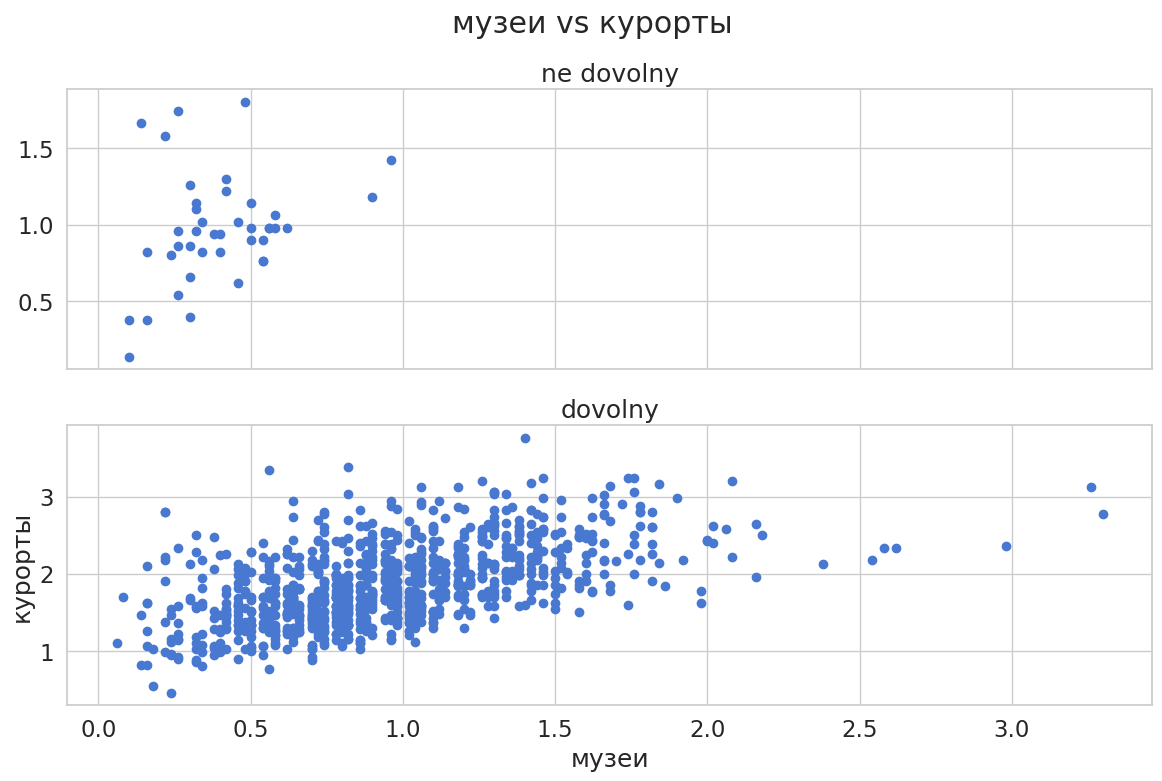

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('музеи vs курорты')

ax1.scatter(n.Category_5, n.Category_6)
ax1.set_title('ne dovolny')

ax2.scatter(d.Category_5, d.Category_6)
ax2.set_title('dovolny')

plt.xlabel('музеи')
plt.ylabel('курорты')
plt.show()

как будто те, кто не доволен в целом, не довольны всем
но в то же время мало кто оценил и музеи, и курорты хорошо, все-таки музеи влияют в какой-то степени на впечатления

оставим ток оценку курорта

In [ ]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.Target_Column == 1]
X_train = X_train.drop(['Target_Column'], axis=1)
y_test = X_test['Target_Column']
X_test = X_test.drop(['Target_Column'], axis=1)

X_train = X_train.values
X_test = X_test.values
y_test = y_test.values
print(y_test.size)

196


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(10, 7),
            nn.Tanh(),
            nn.Linear(7, 4),
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 4),
            nn.Tanh(),
            nn.Linear(4, 10),
            nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


from torch.utils.data import DataLoader, TensorDataset


In [ ]:
model = Autoencoder().double()

In [ ]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

In [ ]:
train_loader = data_utils.DataLoader(X_train, batch_size=minibatch_size, shuffle=True)

In [ ]:
test_loader = data_utils.DataLoader(X_test, batch_size=1, shuffle=False)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)

In [ ]:
history = {}
history['train_loss'] = []
history['test_loss'] = []

In [ ]:
for epoch in range(num_epochs):
    h = np.array([])
    for data in train_loader:

        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)


torch.save(model.state_dict(), './credit_card_model.pth')

epoch [1/100], loss:2.6763
epoch [2/100], loss:2.3615
epoch [3/100], loss:2.0087
epoch [4/100], loss:1.7119
epoch [5/100], loss:1.4356
epoch [6/100], loss:1.2110
epoch [7/100], loss:1.0434
epoch [8/100], loss:0.9108
epoch [9/100], loss:0.8010
epoch [10/100], loss:0.7115
epoch [11/100], loss:0.6350
epoch [12/100], loss:0.5715
epoch [13/100], loss:0.5191
epoch [14/100], loss:0.4706
epoch [15/100], loss:0.4295
epoch [16/100], loss:0.3947
epoch [17/100], loss:0.3652
epoch [18/100], loss:0.3373
epoch [19/100], loss:0.3142
epoch [20/100], loss:0.2932
epoch [21/100], loss:0.2748
epoch [22/100], loss:0.2608
epoch [23/100], loss:0.2473
epoch [24/100], loss:0.2345
epoch [25/100], loss:0.2231
epoch [26/100], loss:0.2148
epoch [27/100], loss:0.2069
epoch [28/100], loss:0.2007
epoch [29/100], loss:0.1943
epoch [30/100], loss:0.1885
epoch [31/100], loss:0.1850
epoch [32/100], loss:0.1819
epoch [33/100], loss:0.1790
epoch [34/100], loss:0.1762
epoch [35/100], loss:0.1742
epoch [36/100], loss:0.1725
e

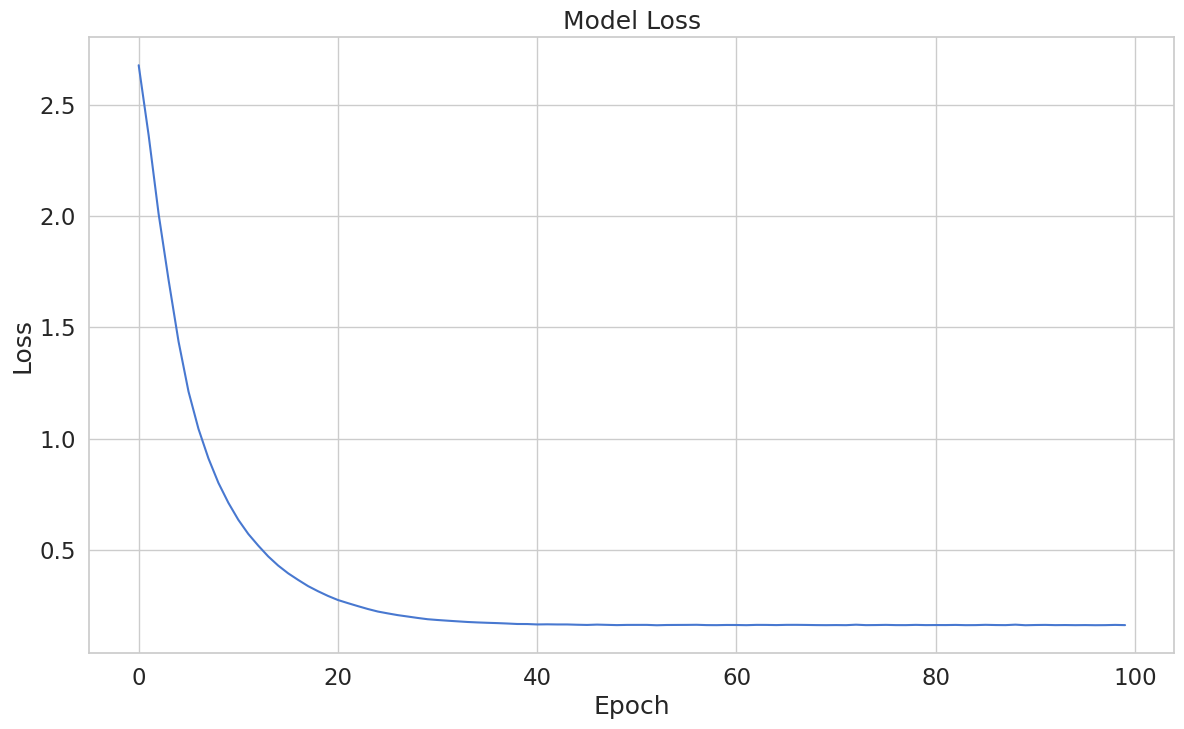

In [ ]:
plt.plot(history['train_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [ ]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
   # test_loss = 0
    for data in test_loader:
        inputs = data
        # print(inputs)
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        #print(loss)
        pred_losses['pred_loss'].append(loss)
        #pred_losses = model([y_test.size, y_test])
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['Target_Column'] = y_test

In [ ]:
reconstructionErrorDF.describe()

,pred_loss,Target_Column
count,196.000000,196.000000
mean,0.186964,1.035714
std,0.148893,0.186052
min,0.017150,1.000000
25%,0.104609,1.000000
50%,0.143304,1.000000
75%,0.232293,1.000000
max,1.198931,2.000000


еще графики

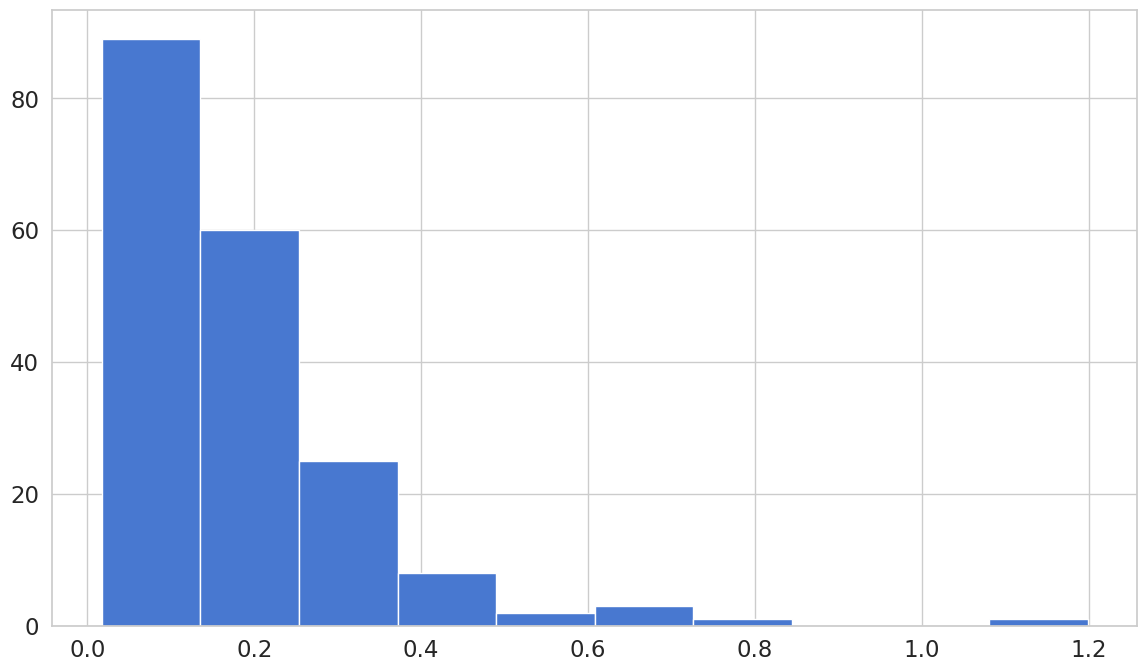

In [ ]:
if 1 in reconstructionErrorDF['Target_Column'].values:
    normal_error_df = reconstructionErrorDF[reconstructionErrorDF['Target_Column'] == 1]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    _ = ax.hist(normal_error_df.pred_loss.values, bins=10)
    plt.show()

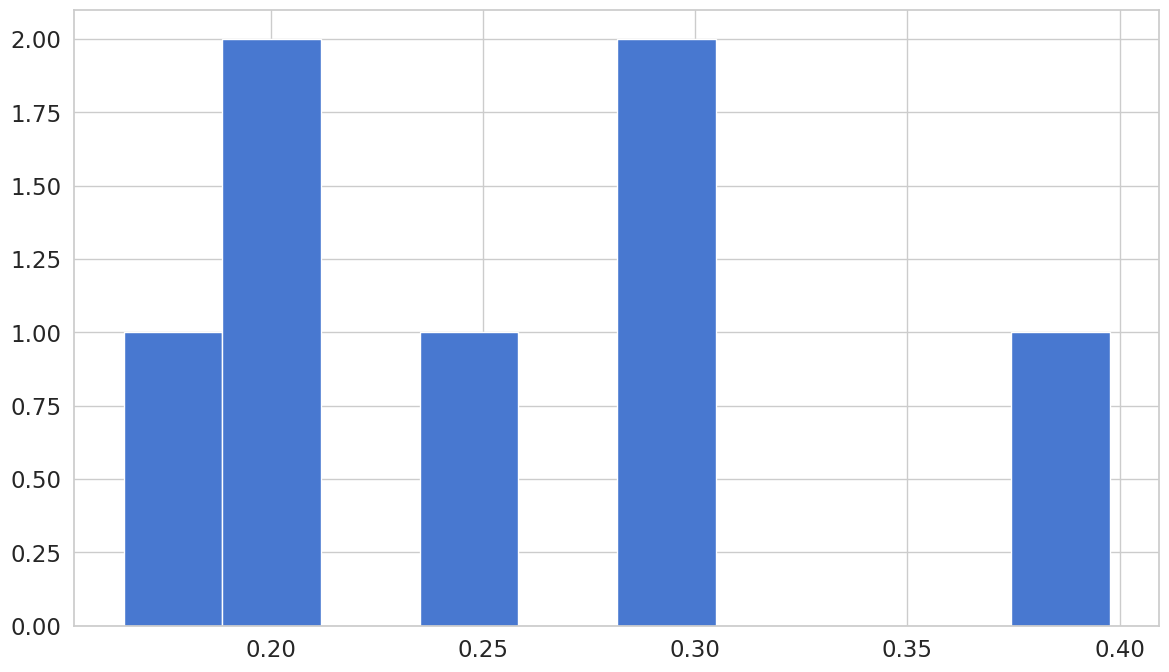

In [ ]:
if 1 in reconstructionErrorDF['Target_Column'].values:
    normal_error_df = reconstructionErrorDF[reconstructionErrorDF['Target_Column'] == 2]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    _ = ax.hist(normal_error_df.pred_loss.values, bins=10)
    plt.show()

roc, графики

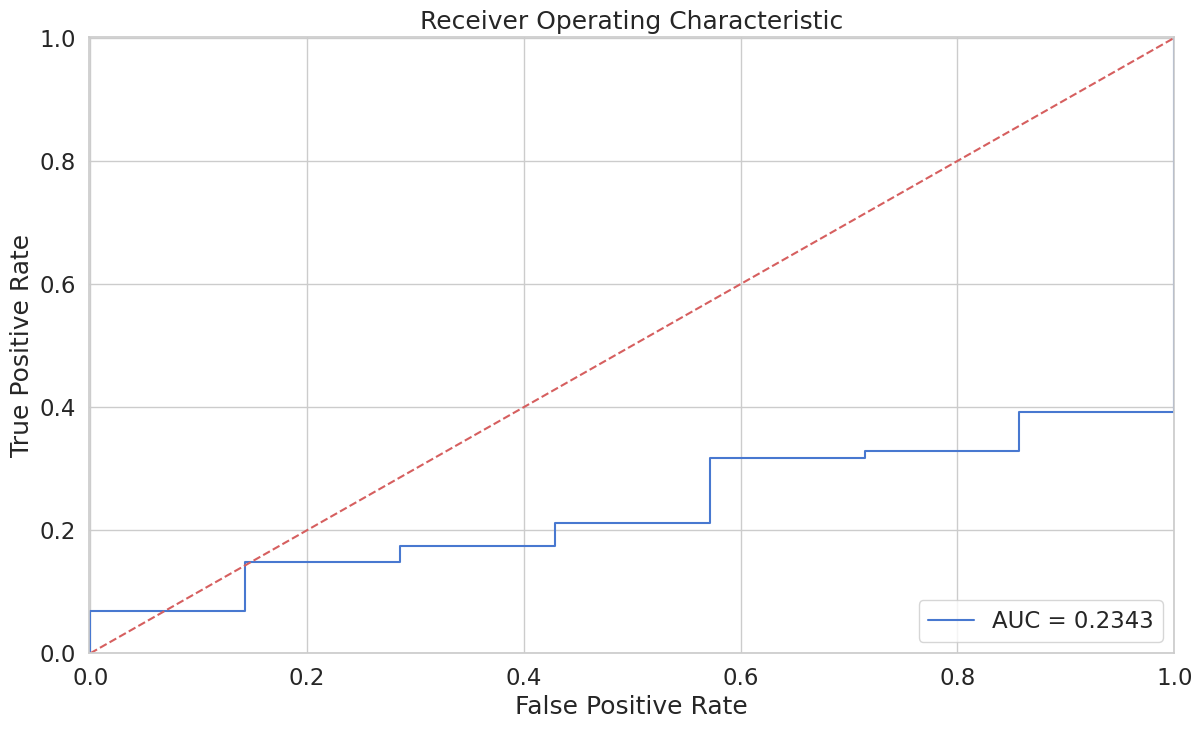

In [ ]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.Target_Column,
                                  reconstructionErrorDF.pred_loss,
                                  pos_label=1)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

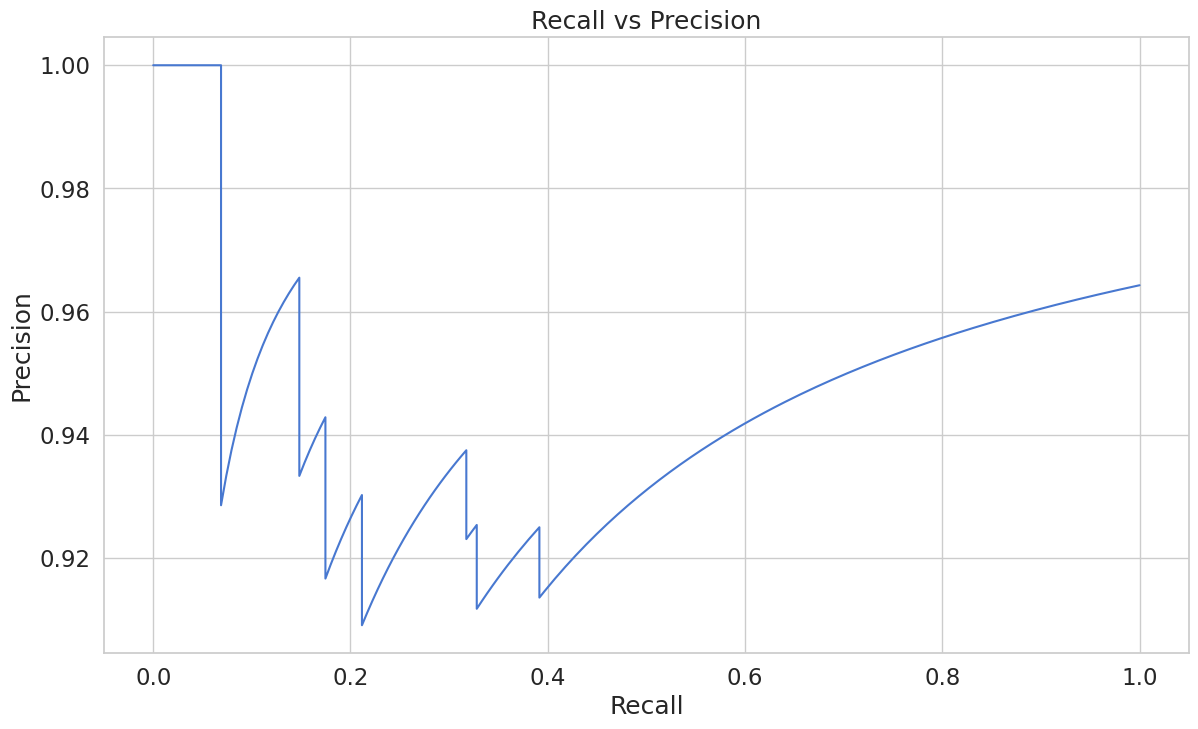

In [ ]:
precision, recall, th = precision_recall_curve(reconstructionErrorDF.Target_Column, reconstructionErrorDF.pred_loss, pos_label=1)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

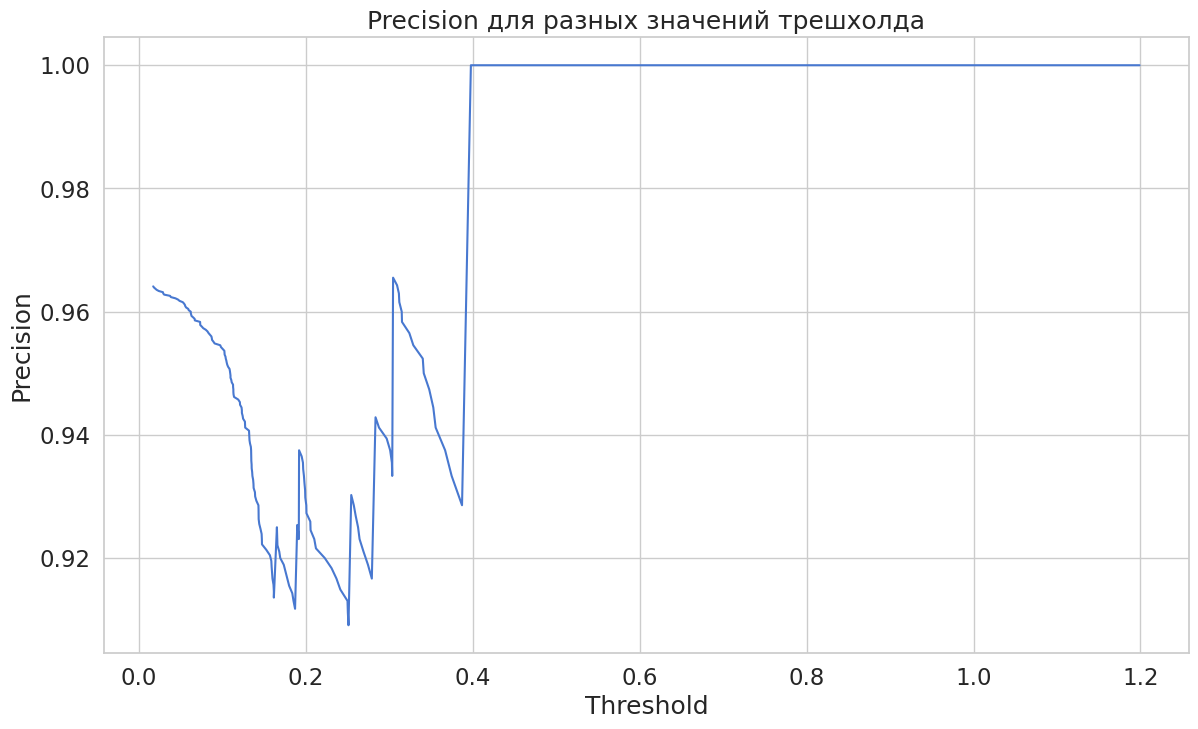

In [ ]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

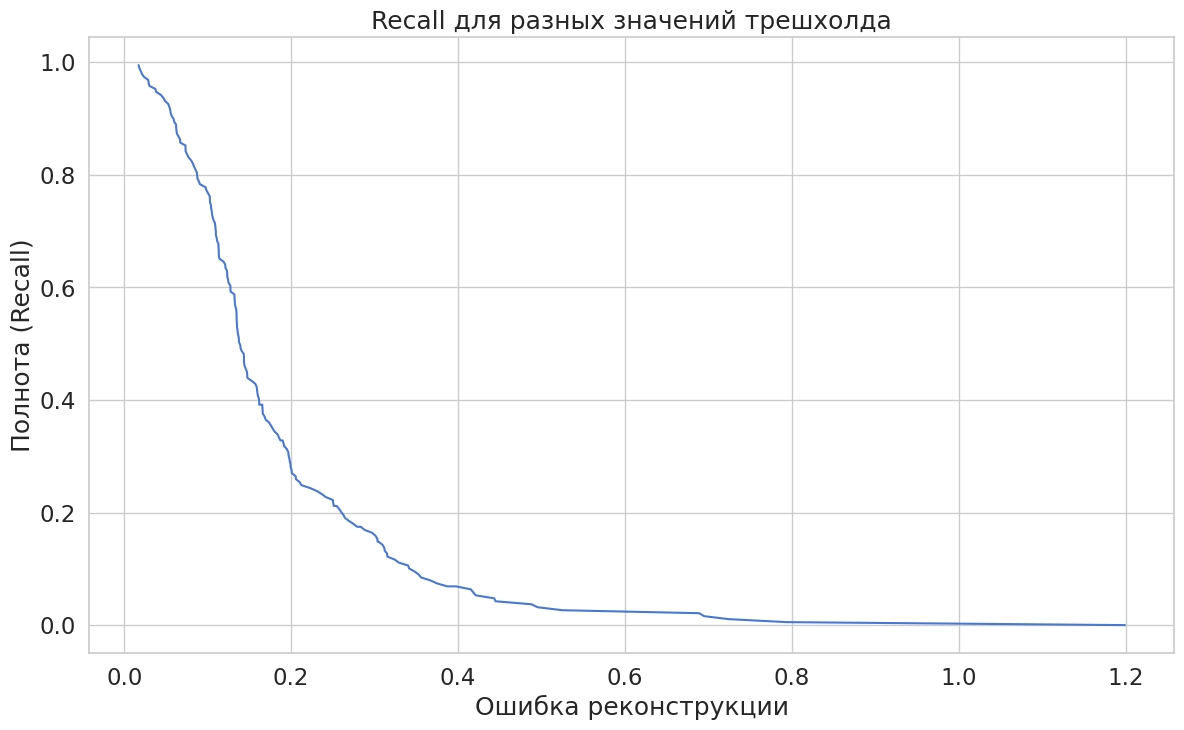

In [ ]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

Здесь мы имеем прямо противоположную ситуацию. По мере увеличения ошибки реконструкции recall уменьшается

In [ ]:
threshold = 2.9

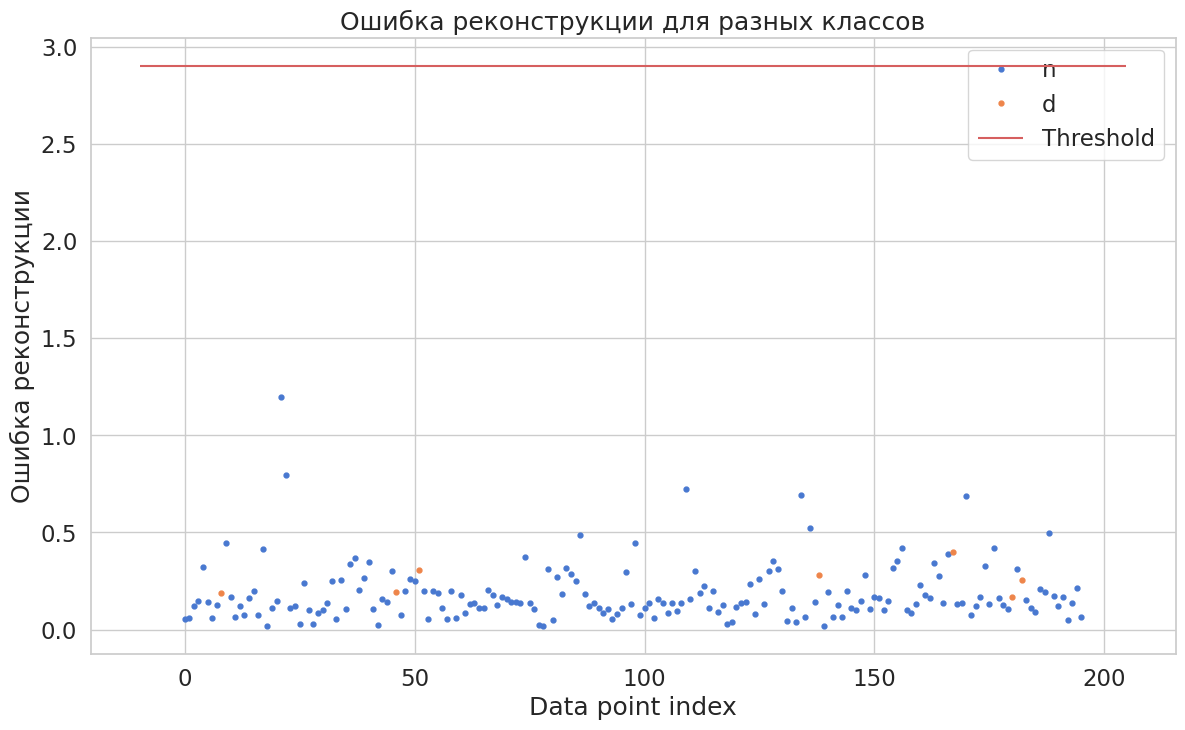

In [ ]:
groups = reconstructionErrorDF.groupby('Target_Column')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "n" if name == 1 else "d")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

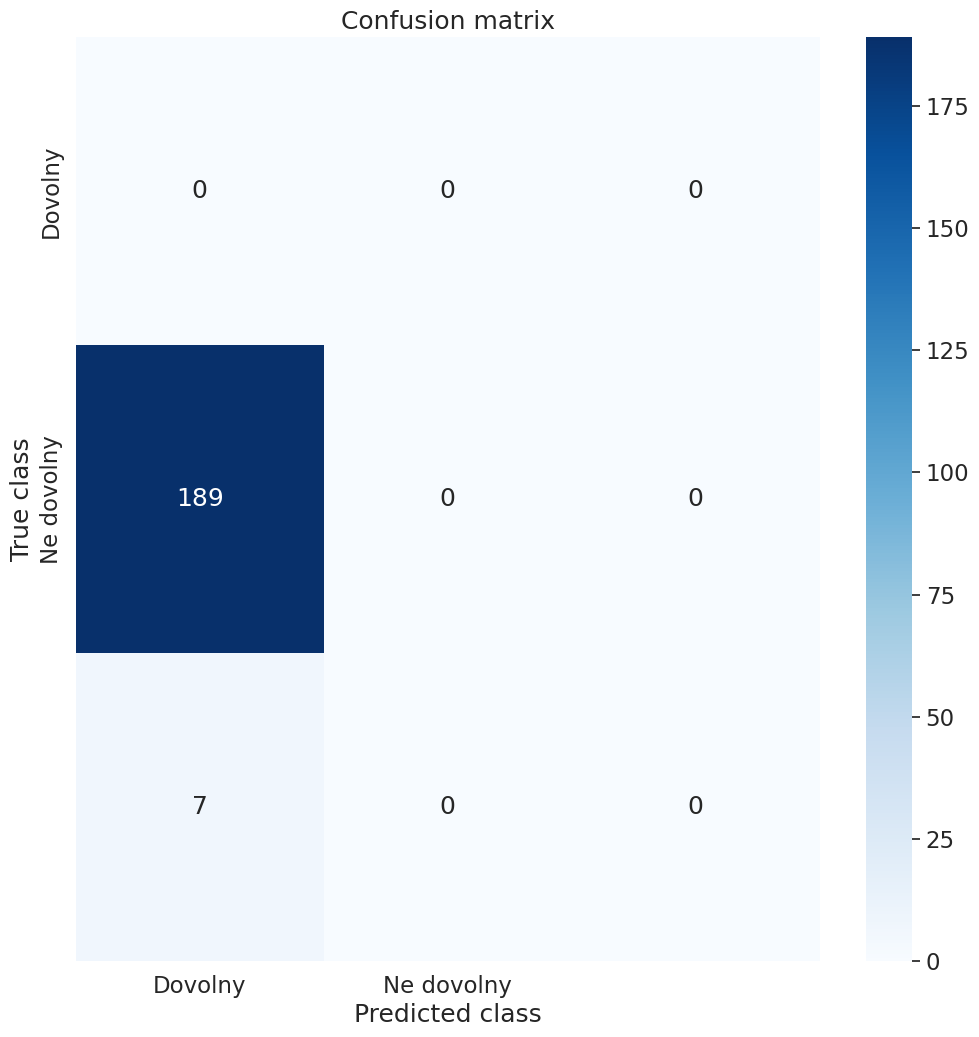

In [ ]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.Target_Column, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'));
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

почему-то их три вместо двух